In [2]:
import os
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import sys

project_root = Path.cwd().parent
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

In [3]:
def find_project_root(marker=".gitignore"):
    current = Path.cwd()
    for parent in [current] + list(current.parents):
        if (parent / marker).exists():
            return parent
    raise FileNotFoundError(f"Could not find {marker} in any parent directory")

PROJECT_ROOT = find_project_root()
DATA_DIR = PROJECT_ROOT / "data"

In [4]:
oc = pd.read_parquet(DATA_DIR / "spy_option_chain.parquet")
oc = oc[(oc['date'].dt.day_of_week < 5) & (oc['date'].dt.day_of_week != 1) & (oc['date'].dt.day_of_week != 3)]

oc.head()

,date,act_symbol,expiration,strike,call_put,bid,ask,vol,delta,gamma,theta,vega,rho
66,2020-01-06,SPY,2020-01-21,275.0,Call,48.52,48.75,0.3116,0.9954,0.0006,-0.0213,0.0087,0.1123
67,2020-01-06,SPY,2020-01-21,275.0,Put,0.03,0.04,0.3175,-0.0052,0.0007,-0.0103,0.0098,-0.0007
68,2020-01-06,SPY,2020-01-21,290.0,Call,33.57,33.78,0.2383,0.9891,0.0018,-0.0278,0.0188,0.1176
69,2020-01-06,SPY,2020-01-21,290.0,Put,0.06,0.07,0.2415,-0.0117,0.0019,-0.0160,0.0201,-0.0016
70,2020-01-06,SPY,2020-01-21,301.0,Call,22.69,22.87,0.1939,0.9689,0.0055,-0.0428,0.0460,0.1194


In [5]:
vh = pd.read_parquet(DATA_DIR / "spy_volatility_history.parquet")

vh.head()

,date,act_symbol,hv_current,hv_week_ago,hv_month_ago,hv_year_high,hv_year_high_date,hv_year_low,hv_year_low_date,iv_current,iv_week_ago,iv_month_ago,iv_year_high,iv_year_high_date,iv_year_low,iv_year_low_date
0,2020-01-04,SPY,0.0776,0.0685,0.0643,0.2923,2020-01-04,0.0549,2019-11-27,0.1171,0.1059,0.1290,0.2311,2020-01-03,0.0886,2019-12-16
1,2020-01-06,SPY,0.0766,0.0715,0.0682,0.2923,2020-01-04,0.0549,2019-11-27,0.1153,0.1204,0.1100,NaN,NaN,NaN,NaN
2,2020-01-08,SPY,0.0780,0.0693,0.0682,0.2907,2020-01-08,0.0549,2019-11-27,0.1098,0.1113,0.1248,NaN,NaN,NaN,NaN
3,2020-01-10,SPY,0.0782,0.0776,0.0683,0.2866,2020-01-10,0.0549,2019-11-27,0.1043,0.1171,0.1200,0.2259,2019-08-05,0.0886,2019-12-16
4,2020-01-13,SPY,0.0794,0.0766,0.0704,0.2802,2019-01-15,0.0549,2019-11-27,0.1000,0.1153,0.0927,0.2259,2019-08-05,0.0886,2019-12-16


In [6]:
sp = pd.read_parquet(DATA_DIR / "spy_prices.parquet")
sp.index.name = 'date'

sp.head()

,Close,High,Low,Open,Volume
date,,,,,
2020-01-02,296.888153,296.906448,294.749706,295.672721,59151200
2020-01-03,294.640076,295.764143,293.442911,293.497741,77709700
2020-01-06,295.764069,295.846313,292.766557,292.885364,55653900
2020-01-07,294.932587,295.672817,294.484772,295.197588,40496400
2020-01-08,296.504272,297.719704,294.877590,295.124324,68296000


In [7]:
#Join options data with price data

merged = oc.merge(sp, left_on='date', right_index = True, how='left')
merged = merged.dropna(subset=["Close"])
merged = merged.reset_index(drop=True)

merged.head()

,date,act_symbol,expiration,strike,call_put,bid,ask,vol,delta,gamma,theta,vega,rho,Close,High,Low,Open,Volume
0,2020-01-06,SPY,2020-01-21,275.0,Call,48.52,48.75,0.3116,0.9954,0.0006,-0.0213,0.0087,0.1123,295.764069,295.846313,292.766557,292.885364,55653900.0
1,2020-01-06,SPY,2020-01-21,275.0,Put,0.03,0.04,0.3175,-0.0052,0.0007,-0.0103,0.0098,-0.0007,295.764069,295.846313,292.766557,292.885364,55653900.0
2,2020-01-06,SPY,2020-01-21,290.0,Call,33.57,33.78,0.2383,0.9891,0.0018,-0.0278,0.0188,0.1176,295.764069,295.846313,292.766557,292.885364,55653900.0
3,2020-01-06,SPY,2020-01-21,290.0,Put,0.06,0.07,0.2415,-0.0117,0.0019,-0.0160,0.0201,-0.0016,295.764069,295.846313,292.766557,292.885364,55653900.0
4,2020-01-06,SPY,2020-01-21,301.0,Call,22.69,22.87,0.1939,0.9689,0.0055,-0.0428,0.0460,0.1194,295.764069,295.846313,292.766557,292.885364,55653900.0


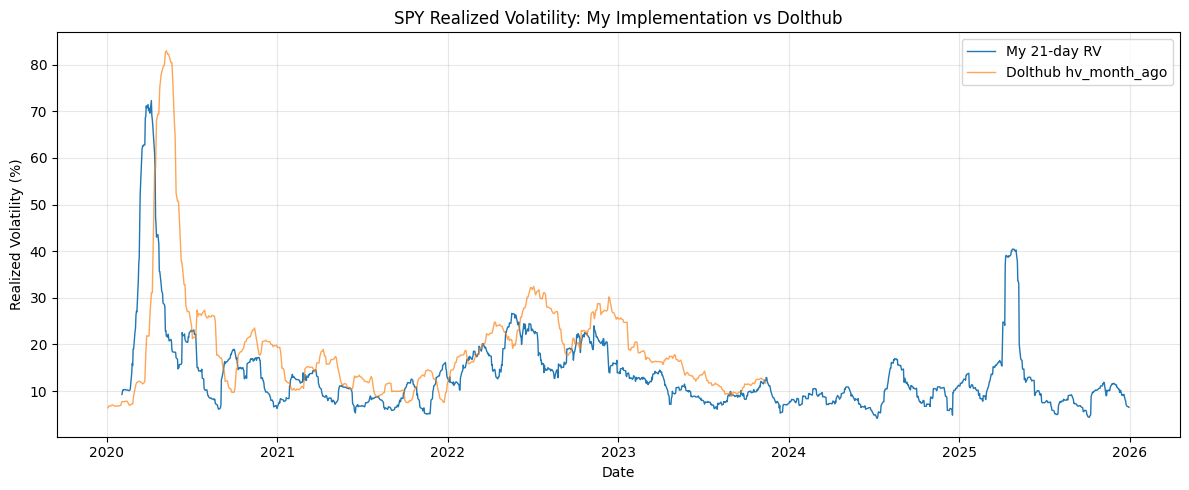

In [16]:
from src.rv_estimators import close_to_close_rv

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
DATA_DIR = PROJECT_ROOT / "data"

sp = pd.read_parquet(DATA_DIR / "spy_prices.parquet")
vh = pd.read_parquet(DATA_DIR / "spy_volatility_history.parquet")

rv_21 = close_to_close_rv(sp["Close"], window=21)

vh = vh.set_index("date").sort_index()

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(rv_21.index, rv_21 * 100, linewidth=1, label="My 21-day RV")
ax.plot(vh.index, vh["hv_month_ago"] * 100, linewidth=1, label="Dolthub hv_month_ago", alpha=0.7)
ax.set_title("SPY Realized Volatility: My Implementation vs Dolthub")
ax.set_xlabel("Date")
ax.set_ylabel("Realized Volatility (%)")
ax.grid(True, alpha=0.3)
ax.legend()
plt.tight_layout()
plt.show()